In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

#**PHASE1**:Understanding the **DATA**

In [20]:
print(df.shape)
print(df.dtypes)
print(df.head())
df.info()

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45    

In [21]:
#We want the total charges to not be object, we want them to be numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_16018/72025802.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'])


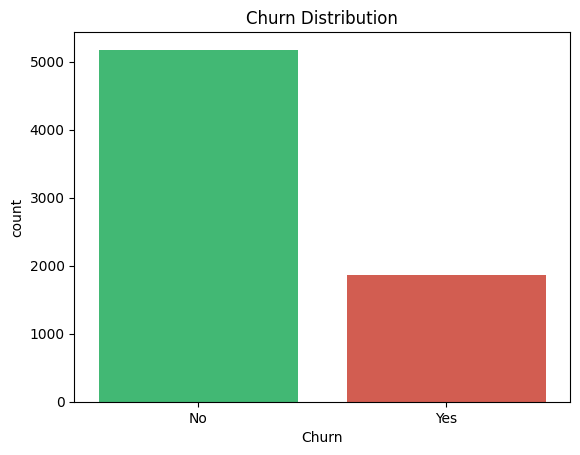

In [22]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(df['Churn'].value_counts(normalize=True)*100)

#Plot
sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title("Churn Distribution")
plt.show()

In [23]:
categorical = df.select_dtypes(include='object').columns.tolist()
numerical = df.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical: ", categorical)
print("Numerical: ", numerical)

Categorical:  ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Numerical:  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


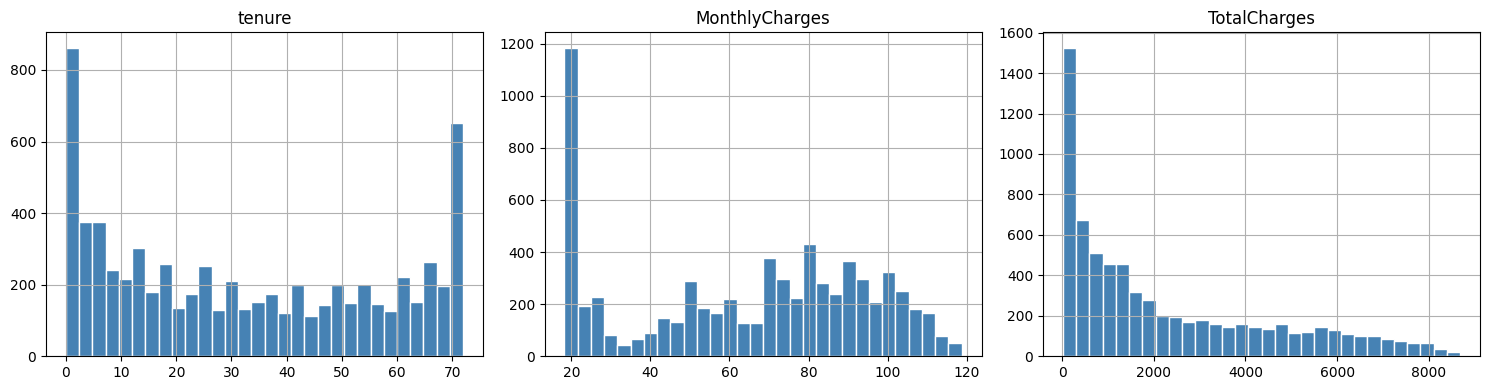

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.show()

1. Tenure: Bimodal graph
2. MonthlyCharges: Not entirely right skewed but it spikes at lower end.
3. TotalCharges: Its right skewed, because its derived from the combination of the factors: tenure and monthly charges.

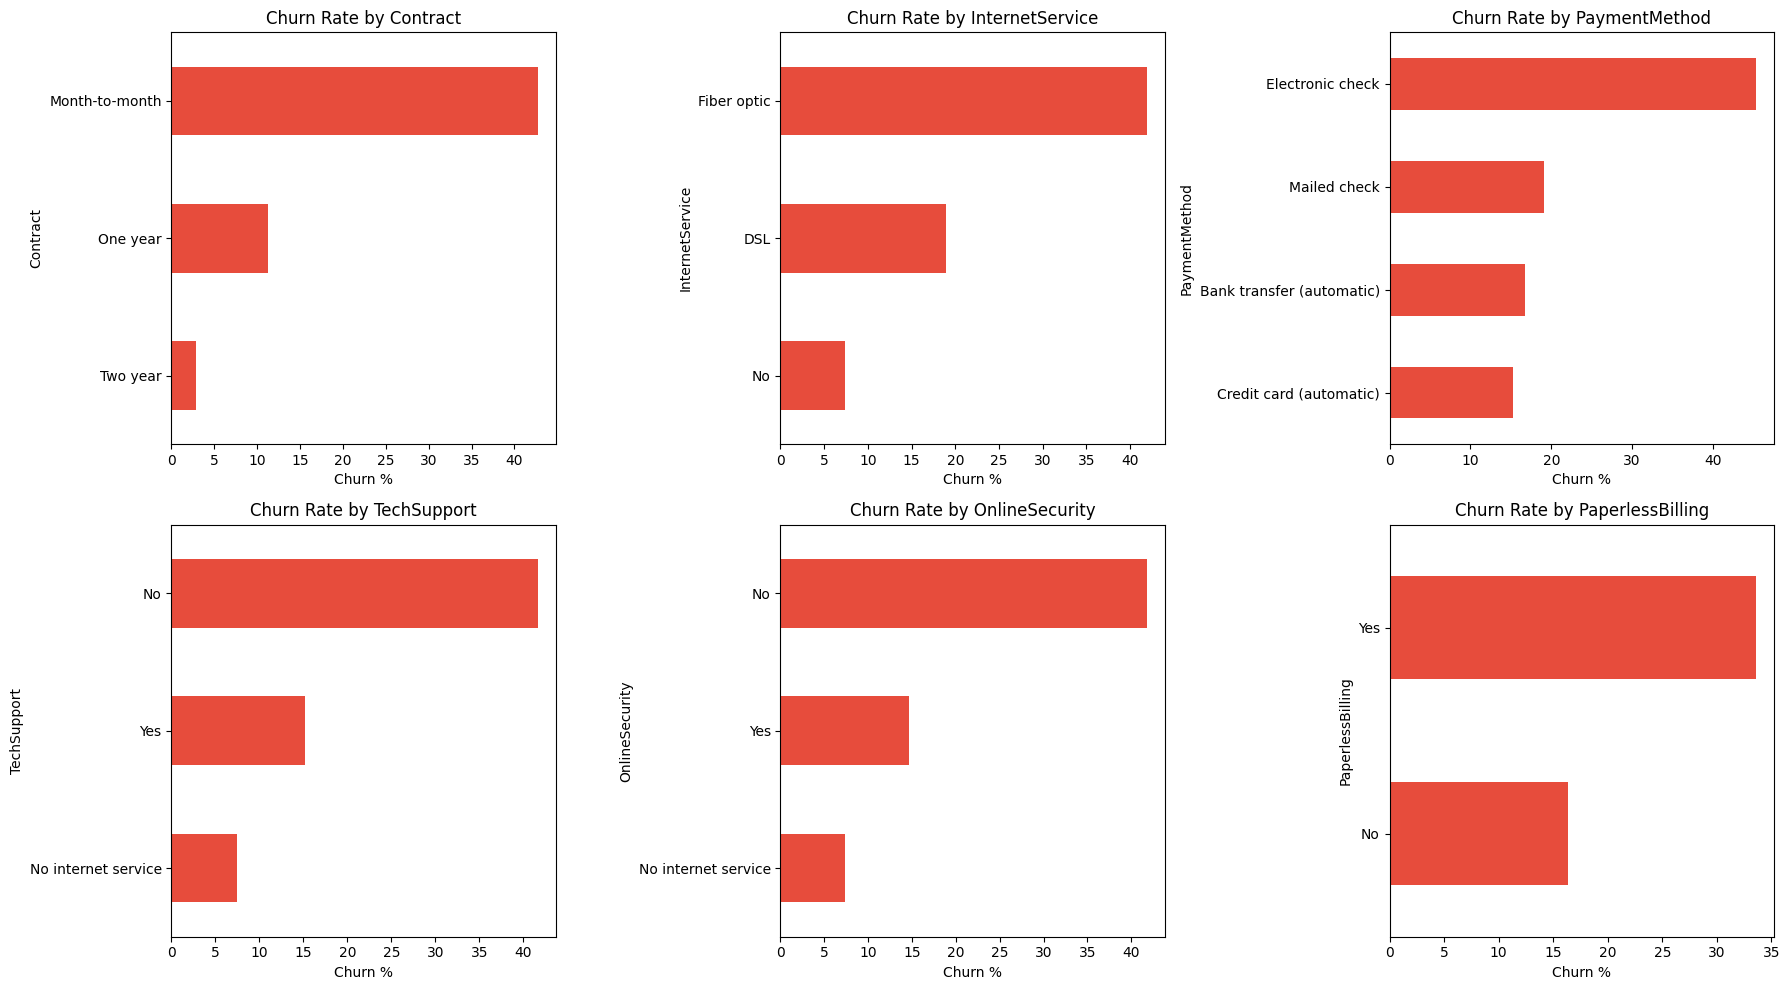

In [25]:
cat_features = ['Contract', 'InternetService', 'PaymentMethod',
                'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), cat_features):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.sort_values().plot(kind='barh', ax=ax, color='#e74c3c')
    ax.set_title(f"Churn Rate by {col}")
    ax.set_xlabel("Churn %")
plt.tight_layout()
plt.show()

1. At first the churn rates in case of no internet connection felt kinda counter-intuitive to me, but after some searches and prompts it makes sense that when there is less internet connection and more landline, the failure points reduce hence the less churn rate, and a major reason also contributes to the use by senior citizens.

2. But in the case of paperless billing, it seems that they get burried under the promotions tab in gmails, and they say that the paper one stays on your countertop, make it a tangible evidence of ur usage. Its also the case that those who use paperless billing, are looking out for competative services, and if it is available at lower prices they shift.

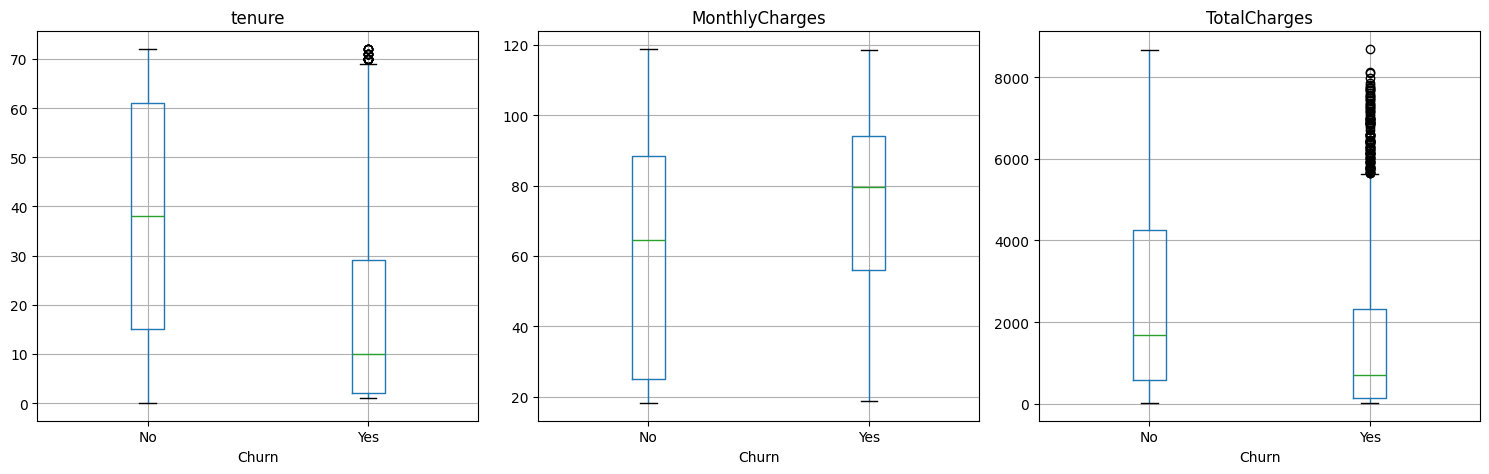

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    df.boxplot(column=col, by='Churn', ax=ax)
    ax.set_title(col)
plt.suptitle("")
plt.tight_layout()
plt.show()

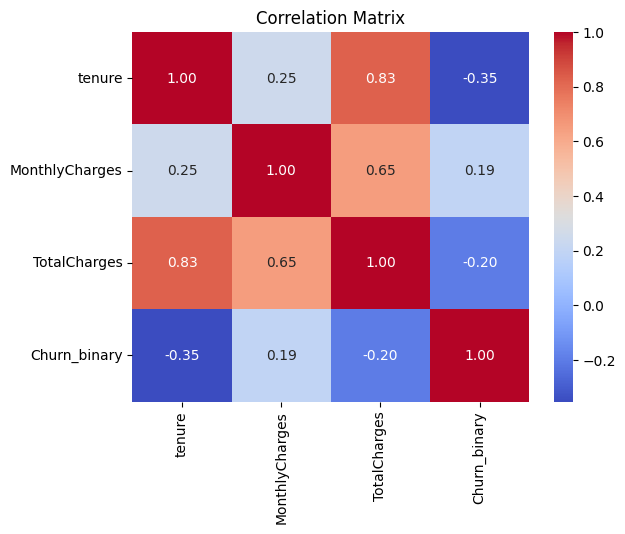

In [27]:
# Encode Churn as binary for correlation
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [28]:
print(df.isnull().sum()[df.isnull().sum() > 0])

TotalCharges    11
dtype: int64


#**PHASE2**: Preprocessing **Pipeline**

In [29]:
df = df.drop(columns=['customerID'])

df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges']=df['TotalCharges'].fillna(0)

df['Churn'] = (df['Churn'] == 'Yes').astype(int)

1. We apply **.fillna** to the **TotalCharges** column because the earlier operation in place of returning `ValueError` returns `NaN`, so we fill those `NaN` value with 0.

2. We also know that the **Churn** column has `yes/no` dtype so we convert it into `1/0`.

In [32]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

binary_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'SeniorCitizen']

multi_cat_features = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                      'OnlineBackup', 'DeviceProtection', 'TechSupport',
                      'StreamingTV', 'StreamingMovies', 'Contract',
                      'PaymentMethod']

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(drop='if_binary', sparse_output=False))
])

multi_cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocesser = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('bin', binary_transformer, binary_features),
    ('cat', multi_cat_transformer, multi_cat_features)
])


`sparse_output=False` it tells the computer to return the a standard, easy to read NumPy array.

In [34]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

We use `stratify=y` so that the test set also behaves same as the original set

In [36]:
X_train_processed = preprocesser.fit_transform(X_train)
X_test_processed = preprocesser.fit_transform(X_test)

print("Train shape: ", X_train_processed.shape)
print("Test shape: ", X_test_processed.shape)

Train shape:  (5634, 40)
Test shape:  (1409, 40)


In [37]:
# Verify no nulls survived
print("Nulls in train:", np.isnan(X_train_processed).sum())
print("Nulls in test:", np.isnan(X_test_processed).sum())

# Check class balance in splits
print("Train churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))
# Both should be ~0.265

Nulls in train: 0
Nulls in test: 0
Train churn rate: 0.265
Test churn rate: 0.265
